# Step 4c: Model Training on Split 2 (K-means Clustering)

**Goal:** Train and evaluate baseline and transformer models on Split 2 to establish performance gap.

**Background:** Step 4b showed that Split 2 (k-means clustering) exhibits meaningful domain shift (79% domain classification accuracy) while Split 1 (control mode) shows none (50%). This notebook retrains all models on Split 2 to:

1. Establish fair baselines trained on Split 2 source domain
2. Measure the actual performance gap between source and target
3. Motivate CORAL domain adaptation

**Split 2 Definition:**
- **Source:** 71 batches (k-means cluster 0) - mixed control modes
- **Target:** 19 batches (k-means cluster 1) - mixed control modes
- Clusters based on DO2/Fs early-window statistics

**Contents:**
1. Setup & Data Loading
2. Ridge Regression Baseline
3. Random Forest Baseline
4. Transformer Training
5. Model Comparison
6. Domain Shift Analysis

In [1]:
import sys
sys.path.insert(0, '..')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from src.data_loader import load_batches
from src.dataset import create_dataloaders
from src.preprocessing import INPUT_FEATURES_EXPANDED as INPUT_FEATURES
from src.baseline_model import RidgeBaseline, train_and_evaluate_baseline
from src.rf_baseline import RandomForestBaseline, train_and_evaluate_rf_baseline
from src.transformer_model import create_model
from src.train import train_and_evaluate, evaluate

sns.set_theme(style='whitegrid')
%matplotlib inline

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Configuration matching step4_transformer
WINDOW_FRACTION = 0.9
MODEL_CONFIG = {
    'patch_len': 16,
    'patch_stride': 8,
    'd_model': 32,
    'n_heads': 8,
    'n_layers': 1,
    'd_ff': 64,
    'dropout': 0.1,
    'pool': 'mean',
    'head_hidden': 32,
}
TRAIN_CONFIG = {
    'n_epochs': 2000,
    'lr': 1e-4,
    'weight_decay': 1e-4,
    'patience': 20,
}

print(f"\nConfiguration:")
print(f"  Window fraction: {WINDOW_FRACTION}")
print(f"  Model: d_model={MODEL_CONFIG['d_model']}, n_layers={MODEL_CONFIG['n_layers']}")

Using device: cpu

Configuration:
  Window fraction: 0.9
  Model: d_model=32, n_layers=1


## 1. Setup & Data Loading

In [2]:
# Load batches
print("Loading batches...")
batches = load_batches()

# Load Split 2 assignments
with open('../outputs/split_assignments.json', 'r') as f:
    split_assignments = json.load(f)

source_ids = split_assignments['clustering']['source']
target_ids = split_assignments['clustering']['target']

print(f"\nSplit 2 (K-means Clustering):")
print(f"  Source: {len(source_ids)} batches")
print(f"  Target: {len(target_ids)} batches")
print(f"  Imbalance: {len(source_ids)/len(target_ids):.1f}:1")
print(f"\n  Target batch IDs: {target_ids}")

Loading batches...

Split 2 (K-means Clustering):
  Source: 71 batches
  Target: 19 batches
  Imbalance: 3.7:1

  Target batch IDs: [5, 11, 13, 15, 17, 19, 27, 35, 37, 53, 55, 59, 67, 71, 75, 77, 81, 85, 87]


In [3]:
# Split source into train/val (80/20)
np.random.seed(42)
source_ids_shuffled = np.random.permutation(source_ids).tolist()
n_val = int(len(source_ids) * 0.2)

val_ids = source_ids_shuffled[:n_val]
train_ids = source_ids_shuffled[n_val:]

print(f"Train/Val/Target split:")
print(f"  Train: {len(train_ids)} batches")
print(f"  Val: {len(val_ids)} batches")
print(f"  Target: {len(target_ids)} batches")

Train/Val/Target split:
  Train: 57 batches
  Val: 14 batches
  Target: 19 batches


## 2. Ridge Regression Baseline

In [4]:
# Train Ridge regression (with normalized y for consistency)
print("Training Ridge Regression on Split 2 source...")

ridge_model = RidgeBaseline(alpha=1.0, normalize_y=True)
ridge_model.fit(batches, train_ids, features=INPUT_FEATURES, window_fraction=WINDOW_FRACTION)

# Evaluate on all splits
ridge_train = ridge_model.evaluate(batches, train_ids, window_fraction=WINDOW_FRACTION)
ridge_val = ridge_model.evaluate(batches, val_ids, window_fraction=WINDOW_FRACTION)
ridge_target = ridge_model.evaluate(batches, target_ids, window_fraction=WINDOW_FRACTION)

print(f"\nRidge Regression Results (metrics in g/L):")
print(f"  Train MAE: {ridge_train['mae']:.2f}")
print(f"  Val MAE: {ridge_val['mae']:.2f}")
print(f"  Target MAE: {ridge_target['mae']:.2f}")
print(f"\n  Performance gap (Target - Val): {ridge_target['mae'] - ridge_val['mae']:.2f}")

Training Ridge Regression on Split 2 source...

Ridge Regression Results (metrics in g/L):
  Train MAE: 0.35
  Val MAE: 1.91
  Target MAE: 8.96

  Performance gap (Target - Val): 7.05


## 3. Random Forest Baseline

In [5]:
# Train Random Forest (with normalized y for consistency)
print("Training Random Forest on Split 2 source...")

rf_model = RandomForestBaseline(n_estimators=200, max_depth=10, random_state=42, normalize_y=True)
rf_model.fit(batches, train_ids, features=INPUT_FEATURES, window_fraction=WINDOW_FRACTION)

# Evaluate on all splits
rf_train = rf_model.evaluate(batches, train_ids, window_fraction=WINDOW_FRACTION)
rf_val = rf_model.evaluate(batches, val_ids, window_fraction=WINDOW_FRACTION)
rf_target = rf_model.evaluate(batches, target_ids, window_fraction=WINDOW_FRACTION)

print(f"\nRandom Forest Results (metrics in g/L):")
print(f"  Train MAE: {rf_train['mae']:.2f}")
print(f"  Val MAE: {rf_val['mae']:.2f}")
print(f"  Target MAE: {rf_target['mae']:.2f}")
print(f"\n  Performance gap (Target - Val): {rf_target['mae'] - rf_val['mae']:.2f}")

Training Random Forest on Split 2 source...

Random Forest Results (metrics in g/L):
  Train MAE: 1.05
  Val MAE: 1.53
  Target MAE: 2.42

  Performance gap (Target - Val): 0.89


## 3b. Cross-Validation Training (Baselines)

Use cross-validation for more robust estimates of source domain performance.

In [6]:
# Cross-validation for Ridge on Split 2 source (with normalized y)
ridge_cv = RidgeBaseline(alpha=1.0, normalize_y=True)
ridge_cv_results = ridge_cv.fit_cv(
    batches,
    train_ids=source_ids,
    features=INPUT_FEATURES,
    window_fraction=WINDOW_FRACTION,
    n_folds=5,
    alphas=[0.01, 0.1, 1.0, 10.0, 100.0],
    random_state=42,
)

# Cross-validation for RF on Split 2 source (with normalized y)
rf_cv = RandomForestBaseline(n_estimators=200, max_depth=10, random_state=42, normalize_y=True)
rf_cv_results = rf_cv.fit_cv(
    batches,
    train_ids=source_ids,
    features=INPUT_FEATURES,
    window_fraction=WINDOW_FRACTION,
    n_folds=5,
    random_state=42,
)

# Evaluate on target
ridge_target_cv = ridge_cv.evaluate(batches, target_ids, window_fraction=WINDOW_FRACTION)
rf_target_cv = rf_cv.evaluate(batches, target_ids, window_fraction=WINDOW_FRACTION)

print("Cross-Validation Results (5-fold on Source) - metrics in g/L")
print("=" * 65)
print(f"{'Metric':<25} {'Ridge':<20} {'Random Forest':<20}")
print("-" * 65)
print(f"{'CV MAE (Source)':<25} {ridge_cv_results['cv_mae']:<20.2f} {rf_cv_results['cv_mae']:<20.2f}")
print(f"{'CV MAE Std':<25} {pd.DataFrame(ridge_cv_results['fold_metrics'])['mae'].std():<20.2f} {pd.DataFrame(rf_cv_results['fold_metrics'])['mae'].std():<20.2f}")
print(f"{'Target MAE':<25} {ridge_target_cv['mae']:<20.2f} {rf_target_cv['mae']:<20.2f}")
print(f"{'Gap (Target - CV)':<25} {ridge_target_cv['mae'] - ridge_cv_results['cv_mae']:<20.2f} {rf_target_cv['mae'] - rf_cv_results['cv_mae']:<20.2f}")
print("=" * 65)
print(f"\nRidge best alpha: {ridge_cv_results['best_alpha']}")

Cross-Validation Results (5-fold on Source) - metrics in g/L
Metric                    Ridge                Random Forest       
-----------------------------------------------------------------
CV MAE (Source)           1.86                 1.99                
CV MAE Std                0.44                 0.60                
Target MAE                6.44                 2.56                
Gap (Target - CV)         4.58                 0.57                

Ridge best alpha: 1.0


## 4. Transformer Training

In [7]:
# Create dataloaders for transformer
data = create_dataloaders(
    source_ids=source_ids,
    target_ids=target_ids,
    batches=batches,
    val_ratio=0.2,
    batch_size=8,
    window_fraction=WINDOW_FRACTION,
    seed=42,
)

print(f"DataLoaders created:")
print(f"  Train: {len(data['train'].dataset)} samples")
print(f"  Val: {len(data['val'].dataset)} samples")
print(f"  Target: {len(data['target'].dataset)} samples")
print(f"  Sequence length: {data['target_len']}")
print(f"  Features: {data['n_features']}")
print(f"  Window fraction: {WINDOW_FRACTION}")
print(f"  Target normalization: y in [0, 1] from [{data['stats']['y_min']}, {data['stats']['y_max']}]")

DataLoaders created:
  Train: 57 samples
  Val: 14 samples
  Target: 19 samples
  Sequence length: 1035
  Features: 25
  Window fraction: 0.9
  Target normalization: y in [0, 1] from [0.0, 50.0]


In [8]:
# Create transformer with current config
model = create_model(
    n_features=data['n_features'],
    seq_len=data['target_len'],
    config=MODEL_CONFIG,
)
model = model.to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model created with {n_params:,} parameters")
print(f"Config: {MODEL_CONFIG}")

Model created with 22,529 parameters
Config: {'patch_len': 16, 'patch_stride': 8, 'd_model': 32, 'n_heads': 8, 'n_layers': 1, 'd_ff': 64, 'dropout': 0.1, 'pool': 'mean', 'head_hidden': 32}


/Users/aless/Desktop/Projects/IndPenSim_Forecast_UDA/notebooks/../src/transformer_model.py:157: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


In [9]:
# Train model with normalized y and denormalized metrics
print("\nTraining transformer on Split 2 source...")
print("="*60)

results = train_and_evaluate(
    model=model,
    train_loader=data['train'],
    val_loader=data['val'],
    target_loader=data['target'],
    device=device,
    verbose=True,
    stats=data['stats'],  # For denormalized metrics
    **TRAIN_CONFIG,
)

print("="*60)
print(f"\nTraining complete!")
print(f"  Best epoch: {results['best_epoch']}")
print(f"  Train MAE: {results['train_metrics']['mae']:.2f} g/L")
print(f"  Val MAE: {results['val_metrics']['mae']:.2f} g/L")
print(f"  Target MAE: {results['target_metrics']['mae']:.2f} g/L")
print(f"\n  Performance gap (Target - Val): {results['target_metrics']['mae'] - results['val_metrics']['mae']:.2f} g/L")


Training transformer on Split 2 source...
Epoch 10/2000 | Train Loss: 0.0076 | Val Loss: 0.0061 | Val MAE: 3.281
Epoch 20/2000 | Train Loss: 0.0054 | Val Loss: 0.0045 | Val MAE: 2.740
Epoch 30/2000 | Train Loss: 0.0036 | Val Loss: 0.0036 | Val MAE: 2.472
Epoch 40/2000 | Train Loss: 0.0030 | Val Loss: 0.0017 | Val MAE: 1.678
Epoch 50/2000 | Train Loss: 0.0030 | Val Loss: 0.0048 | Val MAE: 2.919
Epoch 60/2000 | Train Loss: 0.0026 | Val Loss: 0.0032 | Val MAE: 2.084
Early stopping at epoch 60

=== Final Results ===
Train MAE: 1.384
Val MAE:   1.678
Target MAE: 3.905

Training complete!
  Best epoch: 40
  Train MAE: 1.38 g/L
  Val MAE: 1.68 g/L
  Target MAE: 3.90 g/L

  Performance gap (Target - Val): 2.23 g/L


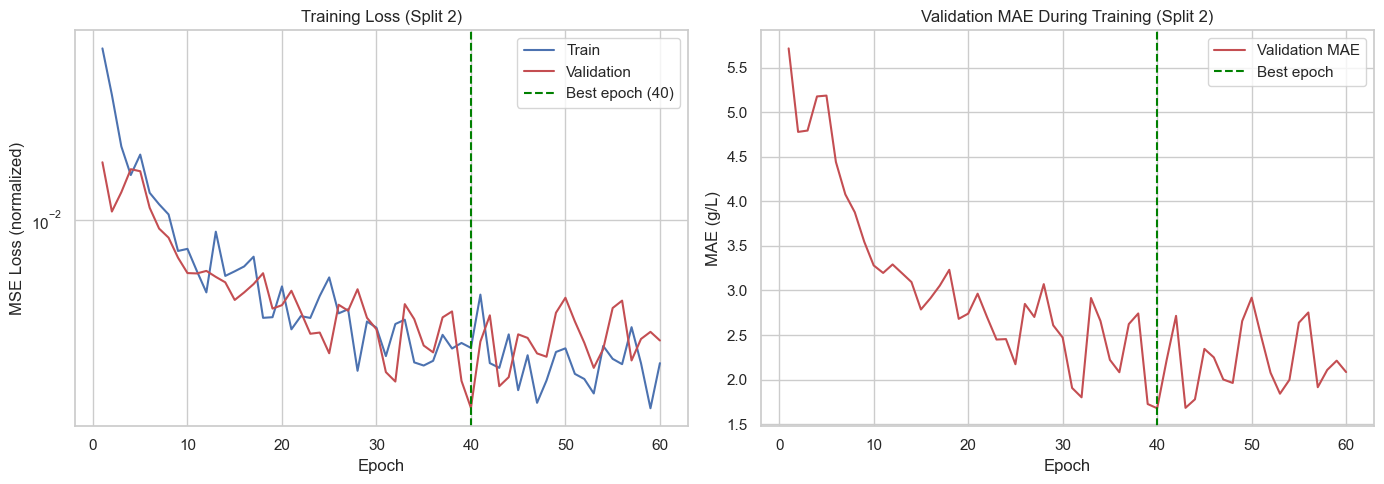

In [10]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

history = results['history']
epochs = range(1, len(history['train_loss']) + 1)

# Loss curves
ax = axes[0]
ax.plot(epochs, history['train_loss'], 'b-', label='Train')
ax.plot(epochs, history['val_loss'], 'r-', label='Validation')
ax.axvline(results['best_epoch'], color='green', linestyle='--', label=f'Best epoch ({results["best_epoch"]})')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss (normalized)')
ax.set_title('Training Loss (Split 2)')
ax.legend()
ax.set_yscale('log')

# MAE curves (in g/L from val_mae in history)
ax = axes[1]
ax.plot(epochs, history['val_mae'], 'r-', label='Validation MAE')
ax.axvline(results['best_epoch'], color='green', linestyle='--', label=f'Best epoch')
ax.set_xlabel('Epoch')
ax.set_ylabel('MAE (g/L)')
ax.set_title('Validation MAE During Training (Split 2)')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/figures/split2_transformer_training.png', dpi=150)
plt.show()

In [11]:
# Save the model
checkpoint = {
    'model_state_dict': model.state_dict(),
    'model_config': MODEL_CONFIG,
    'n_features': data['n_features'],
    'seq_len': data['target_len'],
    'stats': data['stats'],
    'results': {
        'train_mae': results['train_metrics']['mae'],
        'val_mae': results['val_metrics']['mae'],
        'target_mae': results['target_metrics']['mae'],
    },
    'split': 'split2_kmeans',
    'source_ids': source_ids,
    'target_ids': target_ids,
    'window_fraction': WINDOW_FRACTION,
}

torch.save(checkpoint, '../outputs/models/transformer_split2.pt')
print("Model saved to outputs/models/transformer_split2.pt")

Model saved to outputs/models/transformer_split2.pt


## 5. Model Comparison

In [12]:
# Create comparison table (all metrics in g/L)
comparison_data = {
    'Model': ['Ridge Regression', 'Random Forest', 'Transformer'],
    'Train MAE': [ridge_train['mae'], rf_train['mae'], results['train_metrics']['mae']],
    'Val MAE': [ridge_val['mae'], rf_val['mae'], results['val_metrics']['mae']],
    'Target MAE': [ridge_target['mae'], rf_target['mae'], results['target_metrics']['mae']],
    'Train RMSE': [ridge_train['rmse'], rf_train['rmse'], results['train_metrics']['rmse']],
    'Val RMSE': [ridge_val['rmse'], rf_val['rmse'], results['val_metrics']['rmse']],
    'Target RMSE': [ridge_target['rmse'], rf_target['rmse'], results['target_metrics']['rmse']],
}

comparison_df = pd.DataFrame(comparison_data)

# Add performance gap column
comparison_df['Gap (Target-Val)'] = comparison_df['Target MAE'] - comparison_df['Val MAE']

print("\n" + "="*90)
print("SPLIT 2 MODEL COMPARISON (all metrics in g/L)")
print("="*90)
print(comparison_df.to_string(index=False, float_format='%.2f'))
print("="*90)

# Save comparison
comparison_df.to_csv('../outputs/split2_model_comparison.csv', index=False)
print("\nSaved to outputs/split2_model_comparison.csv")


SPLIT 2 MODEL COMPARISON (all metrics in g/L)
           Model  Train MAE  Val MAE  Target MAE  Train RMSE  Val RMSE  Target RMSE  Gap (Target-Val)
Ridge Regression       0.35     1.91        8.96        0.46      2.43        12.26              7.05
   Random Forest       1.05     1.53        2.42        1.47      1.77         2.81              0.89
     Transformer       1.38     1.68        3.90        1.75      2.07         4.40              2.23

Saved to outputs/split2_model_comparison.csv


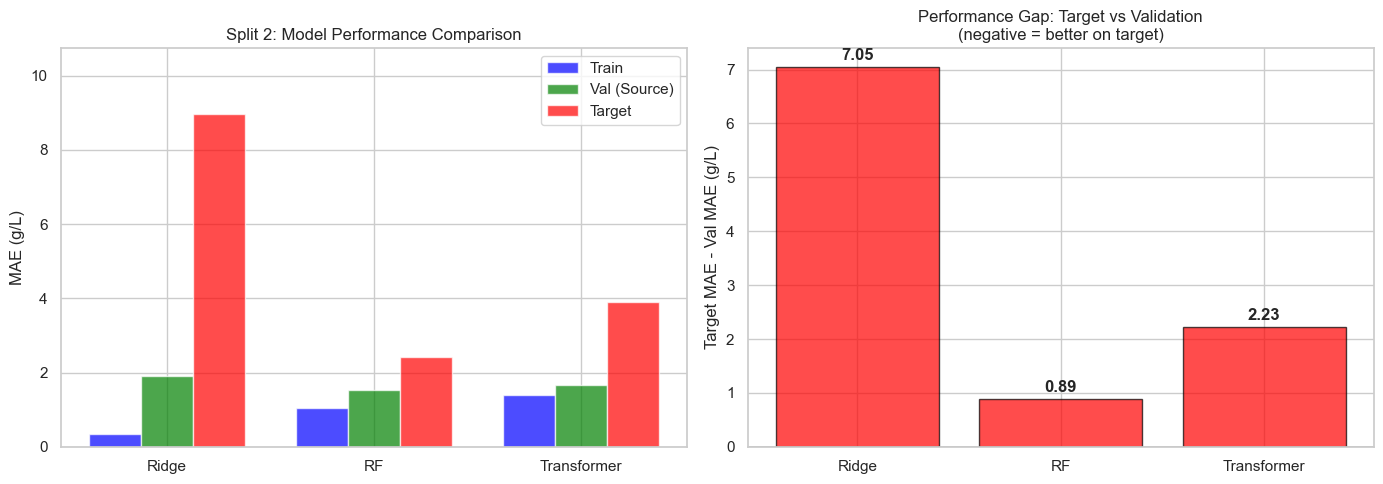

In [13]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = ['Ridge', 'RF', 'Transformer']
x = np.arange(len(models))
width = 0.25

# MAE comparison
ax = axes[0]
ax.bar(x - width, comparison_df['Train MAE'], width, label='Train', color='blue', alpha=0.7)
ax.bar(x, comparison_df['Val MAE'], width, label='Val (Source)', color='green', alpha=0.7)
ax.bar(x + width, comparison_df['Target MAE'], width, label='Target', color='red', alpha=0.7)
ax.set_ylabel('MAE (g/L)')
ax.set_title('Split 2: Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, max(comparison_df['Target MAE'].max(), comparison_df['Val MAE'].max()) * 1.2)

# Performance gap
ax = axes[1]
gaps = comparison_df['Gap (Target-Val)'].values
colors = ['green' if g < 0 else 'red' for g in gaps]
ax.bar(models, gaps, color=colors, alpha=0.7, edgecolor='black')
ax.axhline(0, color='black', linestyle='-', linewidth=1)
ax.set_ylabel('Target MAE - Val MAE (g/L)')
ax.set_title('Performance Gap: Target vs Validation\n(negative = better on target)')

# Add value labels
for i, g in enumerate(gaps):
    ax.annotate(f'{g:.2f}', xy=(i, g), xytext=(0, 5 if g > 0 else -15),
                textcoords='offset points', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/split2_model_comparison.png', dpi=150)
plt.show()

## 6. Domain Shift Analysis

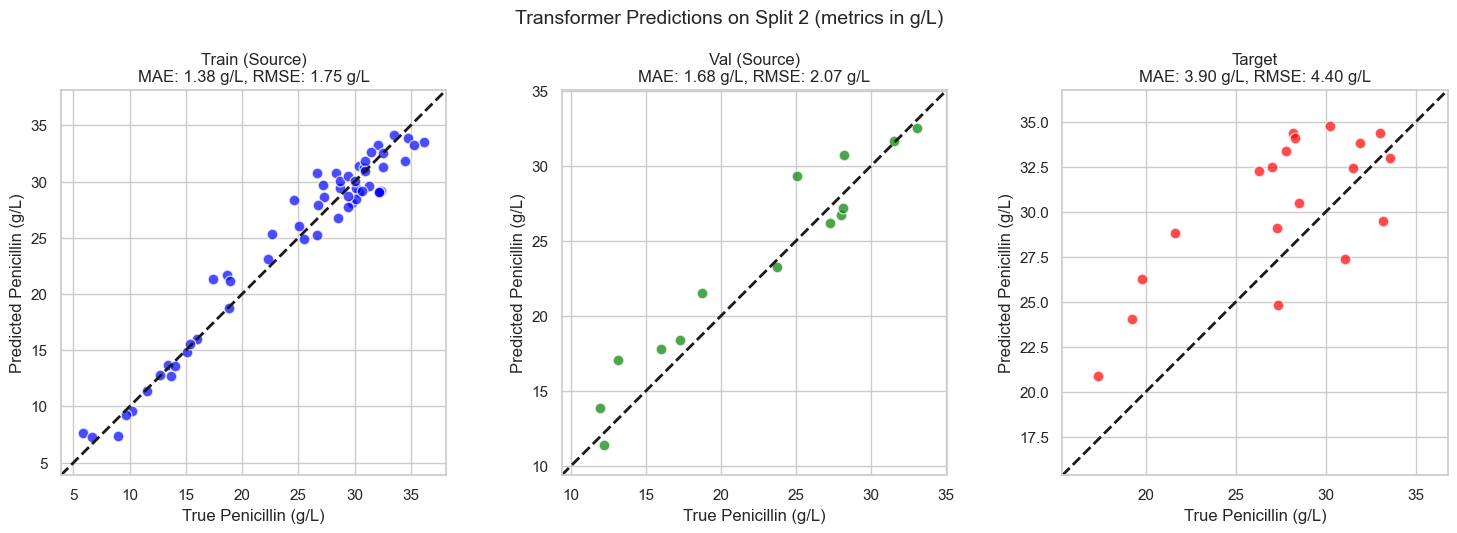

In [14]:
# Scatter plot: predictions vs actuals for each domain (in g/L)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Get transformer predictions (already denormalized from train_and_evaluate)
train_eval = results['train_metrics']
val_eval = results['val_metrics']
target_eval = results['target_metrics']

# Plot each split
for ax, (name, result, color) in zip(axes, [
    ('Train (Source)', train_eval, 'blue'),
    ('Val (Source)', val_eval, 'green'),
    ('Target', target_eval, 'red'),
]):
    ax.scatter(result['targets'], result['predictions'], c=color, alpha=0.7, s=60, edgecolor='white')
    
    # Add diagonal
    all_vals = np.concatenate([result['targets'], result['predictions']])
    min_val, max_val = all_vals.min() - 2, all_vals.max() + 2
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2)
    
    ax.set_xlabel('True Penicillin (g/L)')
    ax.set_ylabel('Predicted Penicillin (g/L)')
    ax.set_title(f'{name}\nMAE: {result["mae"]:.2f} g/L, RMSE: {result["rmse"]:.2f} g/L')
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    ax.set_aspect('equal')

plt.suptitle('Transformer Predictions on Split 2 (metrics in g/L)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/split2_transformer_predictions.png', dpi=150)
plt.show()

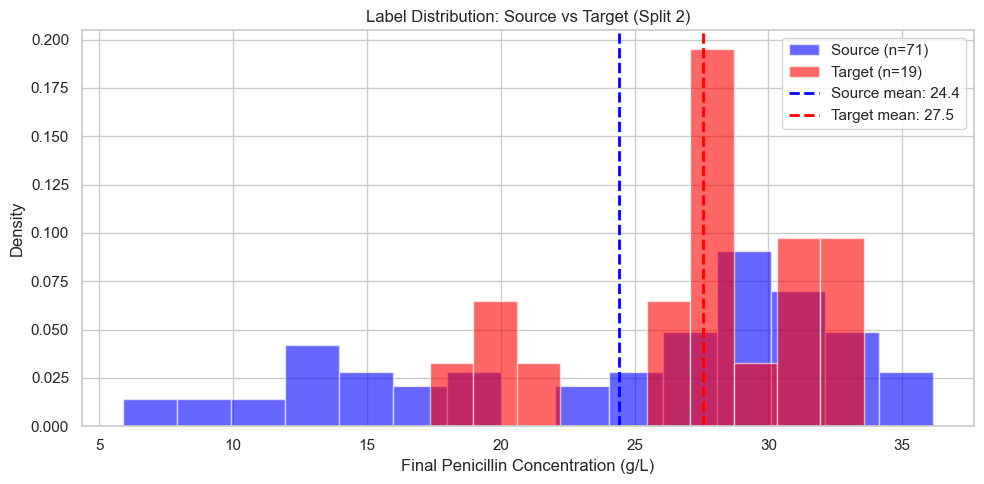

Source domain labels: mean=24.42, std=8.11
Target domain labels: mean=27.54, std=4.73


In [15]:
# Compare target distributions between source and target domains
from src.preprocessing import get_final_target

source_targets = [get_final_target(batches[bid]) for bid in source_ids]
target_targets = [get_final_target(batches[bid]) for bid in target_ids]

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(source_targets, bins=15, alpha=0.6, label=f'Source (n={len(source_targets)})', color='blue', density=True)
ax.hist(target_targets, bins=10, alpha=0.6, label=f'Target (n={len(target_targets)})', color='red', density=True)

ax.axvline(np.mean(source_targets), color='blue', linestyle='--', linewidth=2, label=f'Source mean: {np.mean(source_targets):.1f}')
ax.axvline(np.mean(target_targets), color='red', linestyle='--', linewidth=2, label=f'Target mean: {np.mean(target_targets):.1f}')

ax.set_xlabel('Final Penicillin Concentration (g/L)')
ax.set_ylabel('Density')
ax.set_title('Label Distribution: Source vs Target (Split 2)')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/figures/split2_label_distribution.png', dpi=150)
plt.show()

print(f"Source domain labels: mean={np.mean(source_targets):.2f}, std={np.std(source_targets):.2f}")
print(f"Target domain labels: mean={np.mean(target_targets):.2f}, std={np.std(target_targets):.2f}")